<a href="https://colab.research.google.com/github/AaronYounger/Quantitative-Finance/blob/main/Linear_Modeling_Financial_Market_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-2452386165.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


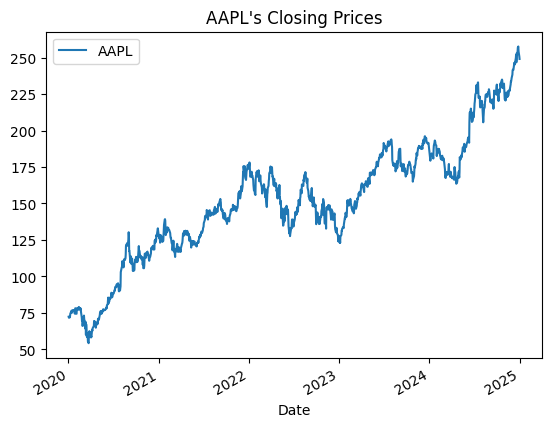

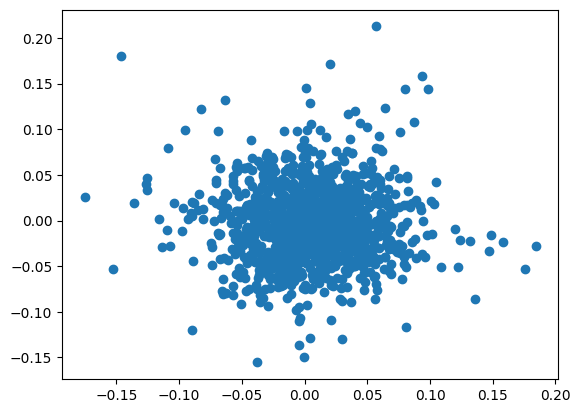

['5d_Close_pct', 'ma20', 'rsi20', 'ma50', 'rsi50', 'ma200', 'rsi200']


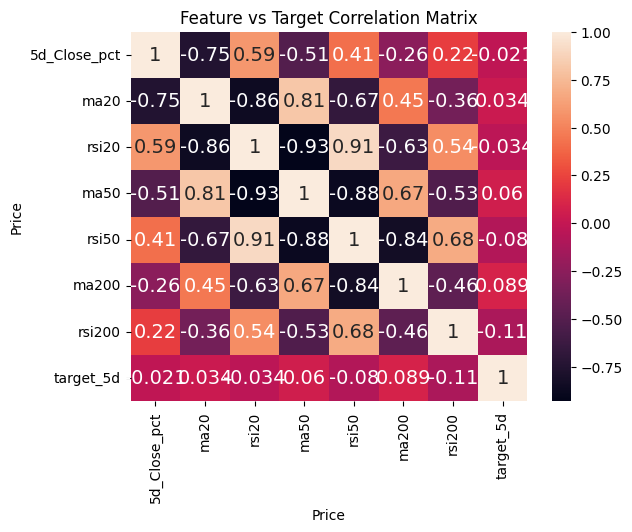

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     5.030
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           1.31e-05
Time:                        04:38:55   Log-Likelihood:                 1696.3
No. Observations:                 895   AIC:                            -3377.
Df Residuals:                     887   BIC:                            -3338.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0475      0.104     -0.458      0.6

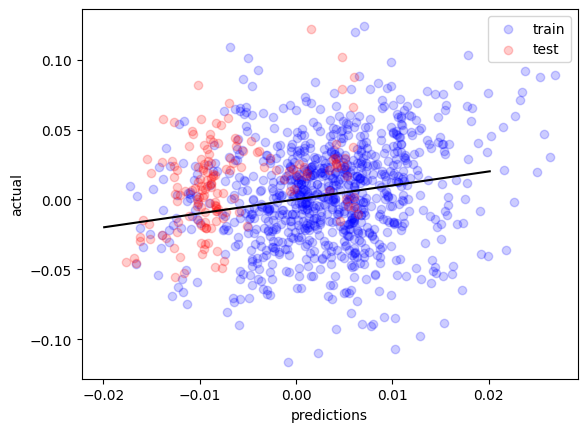

In [ ]:
import statsmodels.api as sm
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Feature = Inputs to Model
# Target = Output of Model

ticker = "AAPL"

class DataCollector:
  def get_data(self, ticker=ticker):
    df = yf.download(
      ticker,
      start="2020-01-01",
      end = "2025-01-01",
      interval = "1d"
    )

    if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)

    df.dropna(inplace=True)
    return df

collector = DataCollector()
df = collector.get_data()

# EDA
## APPL's Closing Prices over Five Years

df.head(5)
df['Close'].plot(label = 'AAPL', legend=True)
plt.title("AAPL's Closing Prices")
plt.show()

# Create 5-day % changes of Adj_Close for the current day, and 5 days in the future

df['5d_Close_pct'] = df['Close'].pct_change(periods=5)
df['5d_future_close'] = df['Close'].shift(-5)
df['5d_future_close_change'] = df['5d_future_close'].pct_change(-5)

plt.scatter(df['5d_Close_pct'], df['5d_future_close_change'])
plt.show()

# Creat Features and Targets

feature_names = ['5d_Close_pct']

# Create MA and RSI Features

for n in [20, 50, 200]:
  df['ma' + str(n)] = ta.sma(df['Close'], length=n)/df['Close']
  df['rsi' + str(n)] = ta.rsi(df['Close'], length=n)
  feature_names = feature_names + ['ma' + str(n), 'rsi' + str(n)]

print(feature_names)

# Plot Heatmap of Features and Target; target = 5d_future_close_change

df['target_5d'] = df['Close'].shift(-5) / df['Close'] -1

ml_df = feature_names + ['target_5d']
corr_df = df[ml_df].dropna()

corr = corr_df.corr()

sns.heatmap(corr, annot=True, annot_kws = {"size": 14})
plt.title("Feature vs Target Correlation Matrix")
plt.show()

X = df[feature_names]
y = df['target_5d']

# Combine and clean together
data = pd.concat([X, y], axis=1)
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

X = data[feature_names]
y = data['target_5d']

features = X.to_numpy()
targets = y.to_numpy()

# Linear Regression Model

linear_features = sm.add_constant(features)
train_size = int(0.85 * targets.shape[0])
train_features = linear_features[:train_size]
train_targets = targets[:train_size]
test_features = linear_features[train_size:]
test_targets = targets[train_size:]

model = sm.OLS(train_targets, train_features)
results = model.fit()

## General Overview
print(results.summary())

## Print P-Values
print(results.pvalues)

train_predictions = results.predict(train_features)
test_predictions = results.predict(test_features)


plt.scatter(train_predictions, train_targets, alpha=0.2, color='b', label='train')
plt.scatter(test_predictions, test_targets, alpha=0.2, color='r', label='test')

# Plot the perfect prediction line
xmin, xmax = plt.xlim()
plt.plot(np.arange(xmin, xmax, 0.01), np.arange(xmin, xmax, 0.01), c='k')

# Set the axis labels and show the plot
plt.xlabel('predictions')
plt.ylabel('actual')
plt.legend()  # show the legend
plt.show()

# The Regression model explains about 3.2% of the variation in 5-day future returns, which seems low but is
# normal for predicting stock returns. Based of the results there are a few features that are statistically
# signficant but the predictive power overall is weak and some indicators are likely multicollinear.
# At the end of the day, what really matters isn’t the R² it’s whether my model can generate profitable
# out-of-sample trading performance after costs.

# In other words markets are noisty and we try to make models to filter through the noise.






In [ ]:
# ===== Predict 5-Day Future Return Using New Unseen Data (robust) ===== Code made with the help of ChatGPT

import numpy as np
import pandas as pd
import statsmodels.api as sm
import pandas_ta as ta

features = feature_names  # your list: ['5d_Close_pct','ma20','rsi20',...]

# Get fresh data
new_df = collector.get_data()

# Recreate features EXACTLY as during training
new_df['5d_Close_pct'] = new_df['Close'].pct_change(periods=5)
for n in [20, 50, 200]:
    new_df[f'ma{n}'] = ta.sma(new_df['Close'], length=n) / new_df['Close']
    new_df[f'rsi{n}'] = ta.rsi(new_df['Close'], length=n)

# Clean like training
new_df = new_df.replace([np.inf, -np.inf], np.nan).dropna()

# Latest row of features (as DataFrame, 1 row)
latest = new_df[features].iloc[[-1]]

# Build exog with a guaranteed constant column in the FIRST position
exog_latest = np.column_stack([np.ones((latest.shape[0], 1)), latest.to_numpy()])

# Sanity check: must match trained exog width
assert exog_latest.shape[1] == results.model.exog.shape[1], (
    f"Feature mismatch: predict has {exog_latest.shape[1]} cols, "
    f"model expects {results.model.exog.shape[1]} cols."
)

# Predict
pred = results.predict(exog_latest)[0]
print(f"Predicted 5-day return: {pred:.4%}")

/tmp/ipython-input-2452386165.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed

Predicted 5-day return: -1.1073%
